<a href="https://colab.research.google.com/github/bladerunner020/Project-Repository/blob/main/ML_Project_Movie_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Advanced House Price Prediction:

Members:  
 - Rakhmonjon Rakhimjonov
 - Muslima Ibrohimova
 - Robiyabonu Qobiljonova
 - Azizakhon Artikova

**1. Introduction**

# Movie Recommendation System

This project builds a Movie Recommendation System using:
- Content-Based Filtering
- Collaborative Filtering

Dataset: MovieLens

Goal:
Recommend movies to users based on preferences and past ratings.

In [1]:
#important setups
!pip install numpy==1.26.4
!pip install scikit-surprise

**2. Import Libraries**

In [2]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Content-based filtering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Collaborative filtering
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

**3. Load Dataset**

In [3]:
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip -o ml-latest-small.zip

--2026-04-27 06:38:18--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip.1’

ml-latest-small.zip 100%[===================>] 955.28K  --.-KB/s    in 0.1s    

2026-04-27 06:38:18 (6.58 MB/s) - ‘ml-latest-small.zip.1’ saved [978202/978202]

Archive:  ml-latest-small.zip
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  


In [4]:
movies = pd.read_csv('ml-latest-small/movies.csv')
ratings = pd.read_csv('ml-latest-small/ratings.csv')

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


**4. Data Understanding**

In [5]:
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

ratings.describe()

Movies: (9742, 3)
Ratings: (100836, 4)


,userId,movieId,rating,timestamp
count,100836.000000,100836.000000,100836.000000,1.008360e+05
mean,326.127564,19435.295718,3.501557,1.205946e+09
std,182.618491,35530.987199,1.042529,2.162610e+08
min,1.000000,1.000000,0.500000,8.281246e+08
25%,177.000000,1199.000000,3.000000,1.019124e+09
50%,325.000000,2991.000000,3.500000,1.186087e+09
75%,477.000000,8122.000000,4.000000,1.435994e+09
max,610.000000,193609.000000,5.000000,1.537799e+09


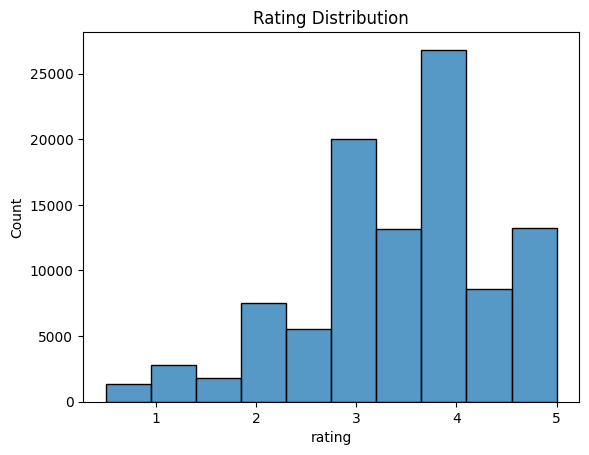

In [6]:
plt.figure()
sns.histplot(ratings['rating'], bins=10)
plt.title("Rating Distribution")
plt.show()

**5. Data Preprocessing**

In [7]:
data = pd.merge(ratings, movies, on='movieId')

# Fill missing genres if any
movies['genres'] = movies['genres'].fillna('')
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


**6. Content-Based Filtering**

In [8]:
#Convert genres → vectors
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(movies['genres'])

In [9]:
#Compute similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [10]:
#Recommendation function
indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()

def recommend_content(title, cosine_sim=cosine_sim):
    idx = indices[title]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    sim_scores = sim_scores[1:11]  # top 10

    movie_indices = [i[0] for i in sim_scores]

    return movies['title'].iloc[movie_indices]

In [11]:
#Test
recommend_content("Toy Story (1995)")

,title
1706,Antz (1998)
2355,Toy Story 2 (1999)
2809,"Adventures of Rocky and Bullwinkle, The (2000)"
3000,"Emperor's New Groove, The (2000)"
3568,"Monsters, Inc. (2001)"
6194,"Wild, The (2006)"
6486,Shrek the Third (2007)
6948,"Tale of Despereaux, The (2008)"
7760,Asterix and the Vikings (Astérix et les Viking...
8219,Turbo (2013)


**7. Collaborative Filtering**

In [12]:
#Prepare data for Surprise
reader = Reader(rating_scale=(0.5, 5.0))
data_surprise = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

trainset, testset = train_test_split(data_surprise, test_size=0.2)

In [13]:
#Train model
model = SVD()
model.fit(trainset)

In [14]:
#Predictions
predictions = model.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8692


0.8691557670832128

**8. Recommendation using Collaborative Filtering**

In [15]:
def recommend_cf(user_id, n=10):
    movie_ids = movies['movieId'].unique()

    predictions = []

    for movie_id in movie_ids:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))

    predictions.sort(key=lambda x: x[1], reverse=True)

    top_movies = predictions[:n]

    movie_indices = [i[0] for i in top_movies]

    return movies[movies['movieId'].isin(movie_indices)]['title']

In [16]:
#Test
recommend_cf(user_id=1)

,title
224,Star Wars: Episode IV - A New Hope (1977)
602,Dr. Strangelove or: How I Learned to Stop Worr...
613,Trainspotting (1996)
863,Monty Python and the Holy Grail (1975)
899,"Princess Bride, The (1987)"
903,"Good, the Bad and the Ugly, The (Buono, il bru..."
906,Lawrence of Arabia (1962)
918,Ran (1985)
926,Amadeus (1984)
975,Cool Hand Luke (1967)


**9. Evaluation**

In [17]:
from sklearn.metrics import mean_squared_error

y_true = [pred.r_ui for pred in predictions]
y_pred = [pred.est for pred in predictions]

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

RMSE: 0.8691557670832128


**10. Conclusion**

This project successfully demonstrates two major recommendation techniques:
content-based and collaborative filtering.

The system can recommend movies based on both item similarity and user behavior.

Future improvements include:
- Deep learning models
- Real-time recommendations
- Handling cold-start problem